In [1]:
pip install kagglehub pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [kagglehub]10 [kagglesdk]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Descarga la última versión del dataset
path = kagglehub.dataset_download("programmer3/lithium-ion-battery-degradation-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 51.0k/51.0k [00:00<00:00, 31.1MB/s]

Extracting files...
Path to dataset files: /Users/axeljohnston/.cache/kagglehub/datasets/programmer3/lithium-ion-battery-degradation-dataset/versions/1


In [3]:
import os

# Listar todos los archivos en la ruta descargada
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Supongamos que hay un archivo llamado 'vanc_batery.csv' (o similar)
# Construimos la ruta completa
archivo_csv = os.path.join(path, archivos[0]) # Toma el primer archivo de la lista

# Cargamos a un DataFrame
import pandas as pd
df = pd.read_csv(archivo_csv)

print("\nPrimeras filas del dataset:")
display(df.head())

Archivos disponibles: ['Battery_dataset.csv']

Primeras filas del dataset:


,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


In [6]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


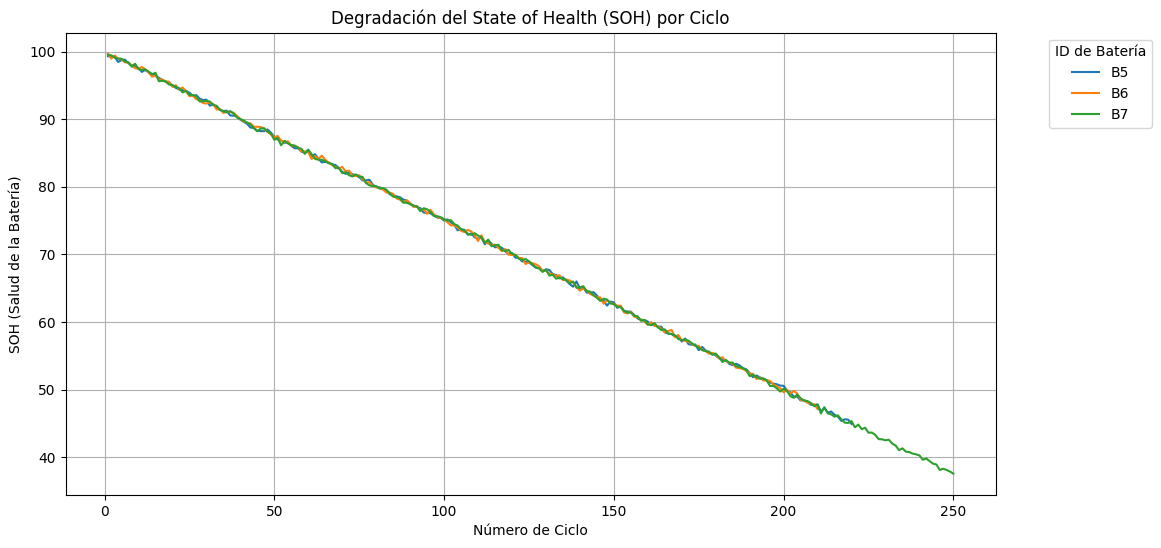

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Usamos SOH que es State of Health (Salud de la batería)
sns.lineplot(data=df, x='cycle', y='SOH', hue='battery_id')

plt.title('Degradación del State of Health (SOH) por Ciclo')
plt.xlabel('Número de Ciclo')
plt.ylabel('SOH (Salud de la Batería)')
plt.grid(True)
plt.legend(title='ID de Batería', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

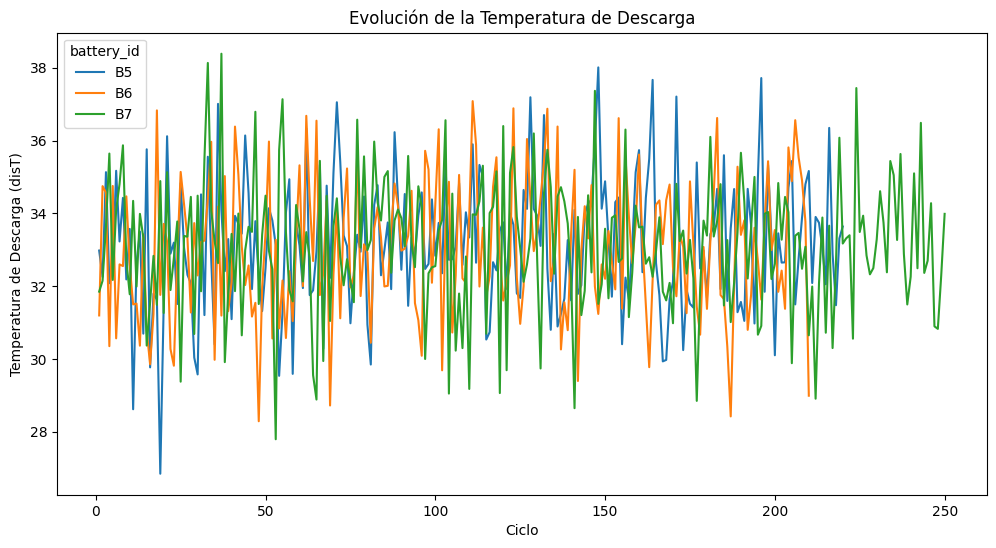

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='cycle', y='disT', hue='battery_id')

plt.title('Evolución de la Temperatura de Descarga')
plt.xlabel('Ciclo')
plt.ylabel('Temperatura de Descarga (disT)')
plt.show()

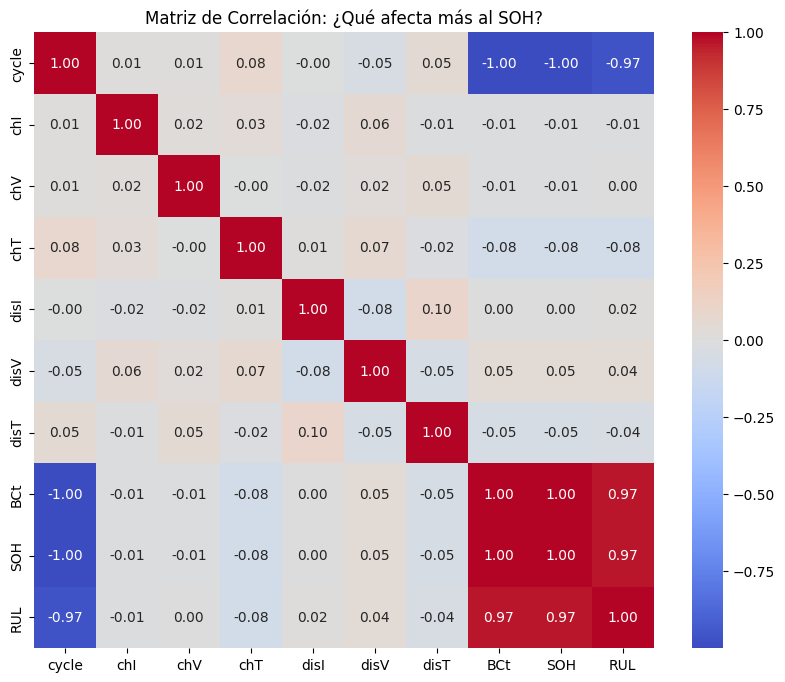

In [10]:
# Seleccionamos solo columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: ¿Qué afecta más al SOH?')
plt.show()

In [12]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 13.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Selección de variables (Features) y objetivo (Target)
# Usaremos variables físicas para predecir la vida restante (RUL)
features = ['cycle', 'SOH', 'disT', 'chT', 'BCt']
X = df[features]
y = df['RUL']

# 2. Dividir datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar un modelo (Bosque Aleatorio es excelente para datos no lineales)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluar
y_pred = model.predict(X_test)
print(f"R2 Score (Precisión): {r2_score(y_test, y_pred):.4f}")
print(f"Error promedio en ciclos: {mean_absolute_error(y_test, y_pred):.2f}")

R2 Score (Precisión): 0.9002
Error promedio en ciclos: 16.97


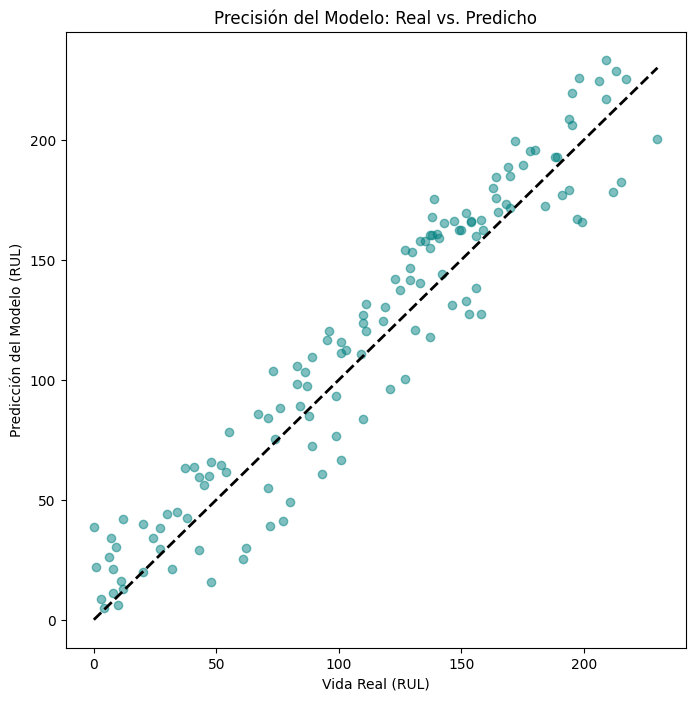

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Vida Real (RUL)')
plt.ylabel('Predicción del Modelo (RUL)')
plt.title('Precisión del Modelo: Real vs. Predicho')
plt.show()

/var/folders/4q/d3kpwqg56fx2c6bffcf0bvkc0000gn/T/ipykernel_26775/2522282559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances, palette='viridis')


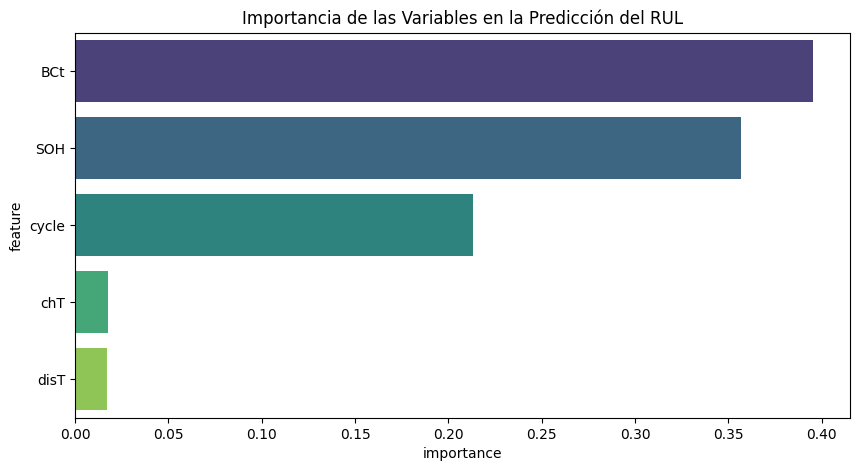

In [15]:
# Ver qué variables influyeron más en el modelo
importances = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('Importancia de las Variables en la Predicción del RUL')
plt.show()